In [7]:
import matplotlib.pyplot as plt

def image_show(imagem):
    """
    Exibe uma imagem usando matplotlib.
    :param imagem: Objeto de imagem PIL
    """
    plt.imshow(imagem)
    plt.show()


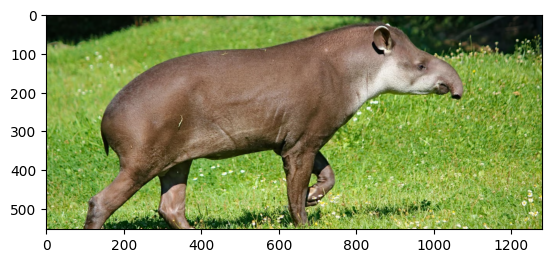

In [8]:
from PIL import Image
imagem = Image.open('./../imagens/anta.png')
image_show(imagem)

In [12]:
from torchvision import transforms


transformer = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean= [0.485, 0.456, 0.406], 
        std = [0.229, 0.224, 0.225])
])

In [14]:
resize_img = transformer(imagem)
resize_img.shape

torch.Size([3, 224, 224])

In [16]:
import torch

batch_image = torch.unsqueeze(resize_img, 0)
batch_image.shape   

torch.Size([1, 3, 224, 224])

In [17]:
from torchvision import models
dir(models)

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'

In [20]:
resnet = models.resnet101(pretrained=True)
resnet.eval()
output = resnet(batch_image)
output

Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /home/altenirmodestogomes/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>

In [ ]:
with open() as classFile:
    ImageNetClassifier = [line.strip() for line in classFile.readlines()]

In [ ]:
_, predicted = torch.max(output, 1)
# predicted 
percent = torch.softmax(output, dim=1)[0] * 100
print(ImageNetClassifier[predicted[0]], percent[predicted[0]].item())   